Just some test

In [169]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [170]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

# import matplotlib
import matplotlib.pyplot as plt

root_dir = os.path.abspath('..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.encoders import Encoder
from src.data_loader.transforms_numpy import polar2cartesian, addSpeckleNoise, energyLoss, addBandReflects


## 1. Encoder test

In [171]:
model_encoder = Encoder(in_ch = 1, out_ch = 128, dim = 32, dropout=0.5)

# for name, param in model.named_parameters():
#     if param.requires_grad:
#         print(f"Warstwa: {name} | Rozmiar: {param.size()} | Liczba elementów: {param.numel()}")


# print(model)

In [ ]:
# example of data
data_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/seq_1/fls/352.png'
new_frame = cv2.imread(data_pth, 0)


from src.data_loader.transforms_numpy import polar2cartesian, addSpeckleNoise, energyLoss, addBandReflects
noise_frame = addBandReflects(new_frame, omega1 = 0.03, omega2 = 0.07, gain = 0.02)
# noise_frame = energyLoss(noise_frame, alpha = 0.02)
noise_frame = addSpeckleNoise(noise_frame, m_min = 30, m_max = 100, sigma = 0.25, beam_width=2.0)
noise_frame = noise_frame.astype(np.uint8)

# print(f'sample size: sample.shape')

sample = torch.from_numpy(noise_frame.copy()) # convert to torch tensor
sample = sample.float()
sample = sample.unsqueeze(0) # add channels num dimension
sample = sample.unsqueeze(0) # add batch size dimension
sample = sample.unsqueeze(0) # add frame num inm series dimension

print(f'tensor shape: {sample.shape}, data type: {sample.dtype}')


tensor shape: torch.Size([1, 1, 1, 800, 768]), data type: torch.float32


In [173]:
# pass through encoder -> downsized 4 times
output = model_encoder(sample)
print(f'output shape: {output.shape}')



output shape: torch.Size([1, 1, 128, 200, 192])


## 2. Patch extraction test

In [174]:
from src.models.patchifier import Patchifier

In [175]:
patchifier = Patchifier(patches_per_frame = 10, patch_size=3, grid_size=(5, 5))

print(f'{sample.shape}')

torch.Size([1, 1, 1, 800, 768])


coords (10, 2)


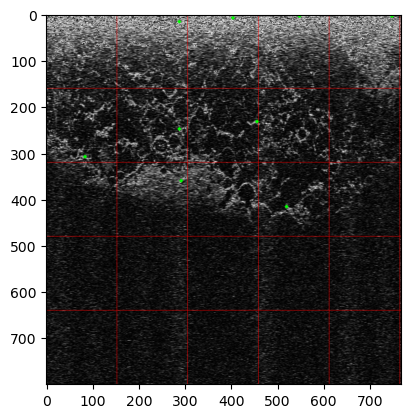

In [176]:
frame_debug = patchifier(sample, mode = 'harris_debug')

plt.figure()
plt.imshow(frame_debug)
plt.show()